# Thesis data overview: acquisition + POC findings

This notebook summarizes where the project stands:

1. **Acquisition (part 1)** — 993 company-fiscal-year DFP filings pulled from CVM: the 66 current non-financial Ibovespa constituents (613 filings) plus 46 more companies found via historical-IBOV reconstruction (380 filings) — every company that was an IBOV member at some point in 2015–2024, not just today's.
2. **POC** — on the full 66-company current universe (originally validated on a 20-company hand-picked subset in rounds 1–2), does isolating the debt note ("empréstimos, financiamentos e debêntures") and comparing it year-over-year with TF-IDF + cosine similarity produce a sane signal? §5 runs the same pipeline on the historical/delisted companies for a stayed-vs-dropped comparison.
3. **Market data (§6)** — the Bloomberg price/index export needed for H1/H1a's dependent variable (future abnormal return) has been received and checked against the acquisition universe.
4. **First look at H1 (§7)** — a POC-scale, market-adjusted (not market-model) abnormal-return check against note similarity, now over the full-universe similarity data. No meaningful relationship yet, as expected without controls — but the full pipeline (note → similarity → event date → return) runs end to end across the whole acquired corpus.
5. **Quarterly pilot (§8)** — does the same approach work on quarterly (ITR) filings instead of annual, and could quarterly frequency catch deterioration sooner than a year-over-year comparison? A first pilot on the same 20-company hand-picked set: extraction reliability transfers reasonably well, but a new quarterly-specific failure mode showed up, and the actual sooner-detection question is still untested.

Full narrative writeup: [`reports/poc_note_extraction_findings.md`](../reports/poc_note_extraction_findings.md). Pipeline code: [`src/acquisition/`](../src/acquisition/), [`src/processing/`](../src/processing/).

**Status: five rounds.** Round 1 established the concept works but flagged note-*isolation* as the weak link. Round 2 fixed four concrete, generalizable extraction bugs found by chasing the round-1 outliers to ground in the actual PDFs, on a 20-company hand-picked subset. Round 3 extended that subset comparison to a first cut of the historical/delisted companies. Round 4 scaled both sides up to the full universe — all 66 current constituents and all confirmed historical/delisted companies — removing the hand-picking, at the cost of a lower reliable-extraction rate and a weaker, no-longer-significant survivorship-bias signal. **Round 5 (this version) hardens extraction itself**, in direct response to round 4 naming it the top priority: four targeted, evidence-based fixes pushed reliable extraction from 44% to 68% on the current-66 universe, found by inspecting real failing PDFs rather than guessing. §8 is a first quarterly-frequency pilot, run alongside round 4 rather than as its own numbered round and not yet updated with round 5's fixes. See the Conclusion for the full comparison.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

ROOT = Path("..")
DATA = ROOT / "data" / "interim"

# Fixed categorical order (never cycled/reassigned) + one-hue sequential ramp,
# per the project's dataviz conventions.
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948",
)
TEXT_PRIMARY, TEXT_SECONDARY, GRID = "#0b0b0b", "#52514e", "#e3e2dd"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": GRID,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "text.color": TEXT_PRIMARY,
    "axes.labelcolor": TEXT_SECONDARY,
    "xtick.color": TEXT_SECONDARY,
    "ytick.color": TEXT_SECONDARY,
    "font.size": 11,
})

DIAG_COLORS = {"font_heading": AQUA, "regex_only": YELLOW, "not_found": RED}
DIAG_LABELS = {"font_heading": "Precisely bounded", "regex_only": "Imprecise fallback", "not_found": "Not found"}

## 1. Acquisition (part 1): what's in the corpus

Non-financial Ibovespa constituents, 2015–2024 DFP filings, pulled from CVM's open-data portal + RAD system (see `src/acquisition/`).

In [2]:
universe = pd.read_csv(DATA / "ibov_non_financial_universe.csv")
log = pd.read_csv(DATA / "ibov_notes_download_log.csv")

n_companies = universe["CD_CVM"].nunique()
n_ok = (log["n_attachments_matched"] > 0).sum()
n_total = len(log)

print(f"{n_companies} non-financial Ibovespa companies")
print(f"{n_ok}/{n_total} company-fiscal-year filings acquired ({n_ok/n_total:.1%})")
print(f"Years covered: {log['ANO'].min()}–{log['ANO'].max()}")

66 non-financial Ibovespa companies
613/613 company-fiscal-year filings acquired (100.0%)
Years covered: 2015–2024


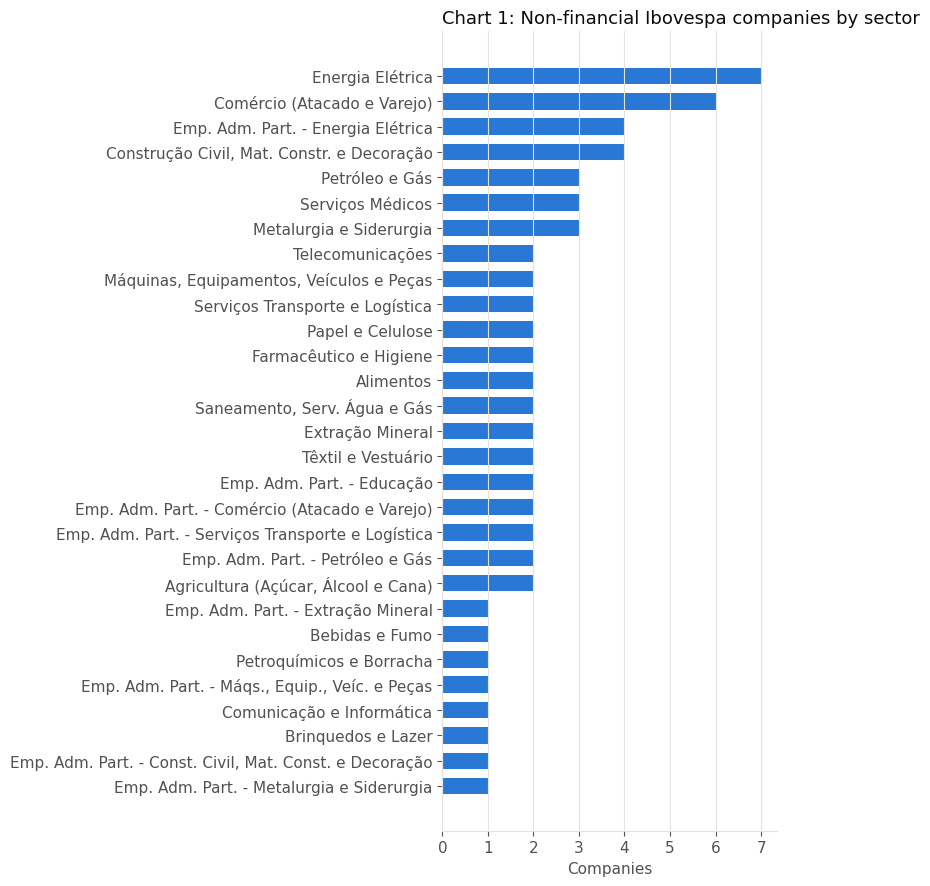

In [3]:
# Companies by sector -- one hue (categorical identity isn't the point here,
# magnitude is), horizontal so the Portuguese sector names stay readable.
sector_counts = (
    universe.drop_duplicates("CD_CVM")["SETOR_ATIV"]
    .value_counts()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(sector_counts.index, sector_counts.values, color=BLUE, height=0.65)
ax.set_xlabel("Companies")
ax.set_title("Chart 1: Non-financial Ibovespa companies by sector", loc="left", fontsize=13, color=TEXT_PRIMARY)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

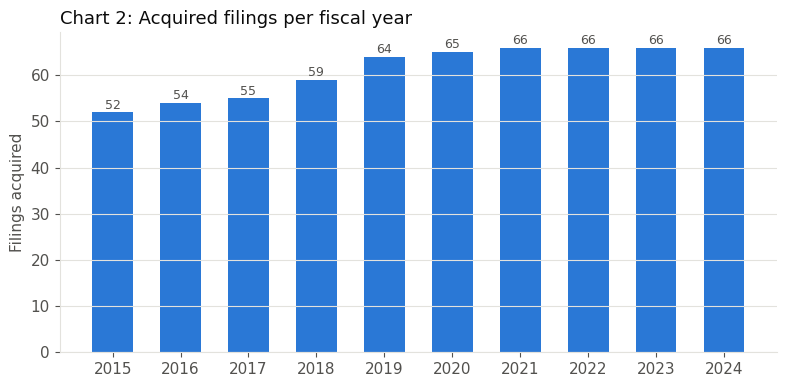

In [4]:
# Filings acquired per fiscal year -- magnitude over an ordered axis, single hue.
by_year = log[log["n_attachments_matched"] > 0].groupby("ANO").size()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(by_year.index.astype(str), by_year.values, color=BLUE, width=0.6)
ax.set_ylabel("Filings acquired")
ax.set_title("Chart 2: Acquired filings per fiscal year", loc="left", fontsize=13, color=TEXT_PRIMARY)
ax.grid(axis="x", visible=False)
for x, y in zip(by_year.index.astype(str), by_year.values):
    ax.text(x, y + 0.8, str(y), ha="center", fontsize=9, color=TEXT_SECONDARY)
fig.tight_layout()
plt.show()

## 2. POC: can the debt note be isolated automatically?

All 66 current non-financial IBOV companies × up to 10 years = 613 company-years, checked against the note-locator in `src/processing/locate_note_section.py`. Three outcomes:

- **`font_heading`** — found a heading visually distinct from body text (bold + larger font). Reliable.
- **`regex_only`** — no visually distinct heading; fell back to "last keyword mention, capped at 500 lines." Imprecise.
- **`not_found`** — no debt-note mention matched at all.

In [5]:
POC = DATA / "poc"

current_cd_cvm = {f"{int(c):06d}" for c in universe["CD_CVM"]}
sections = pd.DataFrame(
    json.loads(p.read_text(encoding="utf-8"))
    for p in sorted((POC / "sections").glob("*.json"))
    if p.stem.split("_")[0] in current_cd_cvm
)
sections["chars"] = sections["text"].str.len()

diag_counts = sections["diagnostic"].value_counts().reindex(["font_heading", "regex_only", "not_found"])
for diag, n in diag_counts.items():
    print(f"{DIAG_LABELS[diag]:22s} {n:3d}/{len(sections)}  ({n/len(sections):.0%})")

Precisely bounded      416/613  (68%)
Imprecise fallback     158/613  (26%)
Not found               39/613  (6%)


**Round 5: extraction hardening, done after round 4 flagged it as the top priority.** The jump from round 4's 44% to 68% reliable extraction here comes from four targeted fixes, each found by directly inspecting real failing PDFs' font/styling data (not guessed at), then validated against known-good controls (WEG, Vale) to confirm no regression:

1. **PDF native bookmarks** — a small, free win (~9 filings) where the filer's own document software embedded a navigable outline.
2. **Same-size headings (bold + ALL-CAPS, or bold + numbered prefix)** — the biggest single fix. Some filers (Gerdau, Petrobras-style companies) never make note headings visually larger than body text at all; the heading is only distinguished by being bold *and* capitalized or numbered. This alone explained **22 companies with a 0% reliable-extraction rate across every year checked**.
3. **Non-bold caps+numbered headings** — a few filers style headings as ALL-CAPS with a numbered prefix but no bold at all; requiring both signals together (not just one) keeps this from over-firing on ordinary body text.
4. **"Debênture" alone as a qualifying keyword** — the original heuristic required 2 of 3 keyword stems in one line, which missed filers whose combined debt note is titled plainly "Debêntures" (no "Empréstimos e Financiamentos" in the same heading). "Debênture" alone is unambiguous, unlike "empréstimo" alone (which also appears in unrelated headings like cash-flow-statement line items).

Two ideas were investigated and deliberately **not** implemented: a table-of-contents/index-page detector (checked empirically — only 1.4% of remaining failures would benefit, not worth the complexity) and following explicit "Nota N" cross-references to a different location in the document (26% of failures mention one, but only ~26% of *those* actually resolve to real content — the same reference number collides with unrelated table values elsewhere in the document too often to trust automatically). Full detail in `reports/poc_note_extraction_findings.md` §9.

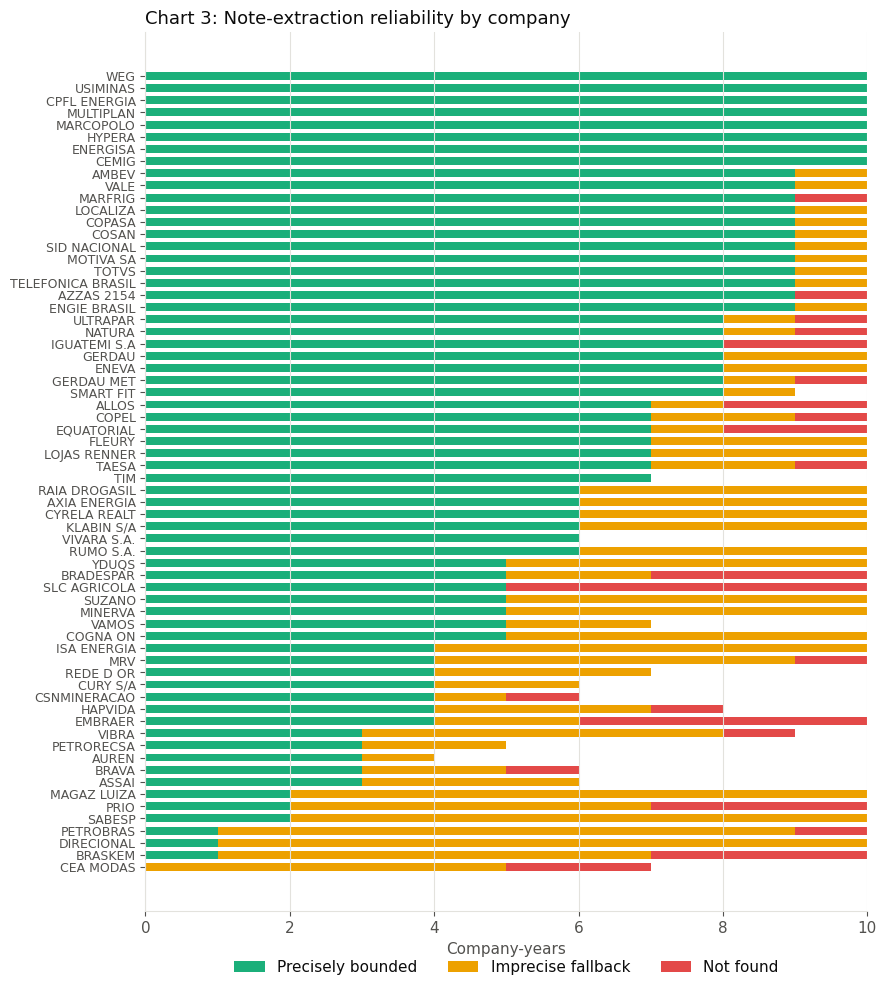

In [6]:
# Per-company reliability, ordered by how often extraction succeeded cleanly --
# status-style colors (green=reliable, amber=imprecise, red=missing), fixed order.
pivot = (
    sections.groupby(["name", "diagnostic"]).size().unstack(fill_value=0)
    .reindex(columns=["font_heading", "regex_only", "not_found"], fill_value=0)
)
pivot = pivot.loc[pivot["font_heading"].sort_values().index]

fig, ax = plt.subplots(figsize=(9, 10))
left = pd.Series(0, index=pivot.index)
for diag in ["font_heading", "regex_only", "not_found"]:
    ax.barh(pivot.index, pivot[diag], left=left, color=DIAG_COLORS[diag], label=DIAG_LABELS[diag], height=0.65)
    left = left + pivot[diag]

ax.set_xlabel("Company-years")
ax.set_title("Chart 3: Note-extraction reliability by company", loc="left", fontsize=13, color=TEXT_PRIMARY)
ax.tick_params(axis="y", labelsize=9)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.04), ncol=3, frameon=False)
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

## 3. Does the similarity measure make sense?

Year-over-year TF-IDF cosine similarity, fit across the whole POC corpus so IDF reflects cross-sectional boilerplate (the same logic the literature relies on). Comparing **all pairs** to pairs where **both years got a reliable extraction** shows the distribution tightening up substantially once extraction noise is controlled for.

In [7]:
results = pd.read_csv(POC / "similarity_results.csv")
both_reliable = results[(results["diagnostic_prev"] == "font_heading") & (results["diagnostic_curr"] == "font_heading")]

print("All pairs:            n={:3d}  mean={:.2f}  median={:.2f}".format(
    len(results), results["cosine_similarity"].mean(), results["cosine_similarity"].median()))
print("Both years reliable:  n={:3d}  mean={:.2f}  median={:.2f}".format(
    len(both_reliable), both_reliable["cosine_similarity"].mean(), both_reliable["cosine_similarity"].median()))

All pairs:            n=508  mean=0.56  median=0.69
Both years reliable:  n=313  mean=0.73  median=0.84


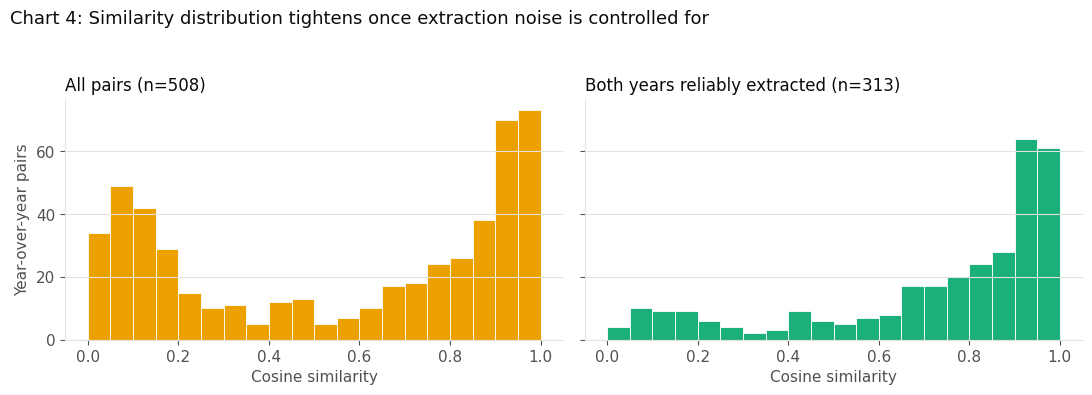

In [8]:
# Small multiples (same measure, two filters) rather than an overlaid
# histogram -- cleaner to compare than two semi-transparent fills.
bins = [i / 20 for i in range(21)]
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True, sharex=True)

axes[0].hist(results["cosine_similarity"], bins=bins, color=YELLOW, edgecolor="white", linewidth=0.6)
axes[0].set_title(f"All pairs (n={len(results)})", loc="left", fontsize=12, color=TEXT_PRIMARY)

axes[1].hist(both_reliable["cosine_similarity"], bins=bins, color=AQUA, edgecolor="white", linewidth=0.6)
axes[1].set_title(f"Both years reliably extracted (n={len(both_reliable)})", loc="left", fontsize=12, color=TEXT_PRIMARY)

for ax in axes:
    ax.set_xlabel("Cosine similarity")
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("Year-over-year pairs")
fig.suptitle("Chart 4: Similarity distribution tightens once extraction noise is controlled for", x=0.01, ha="left", fontsize=13, color=TEXT_PRIMARY)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

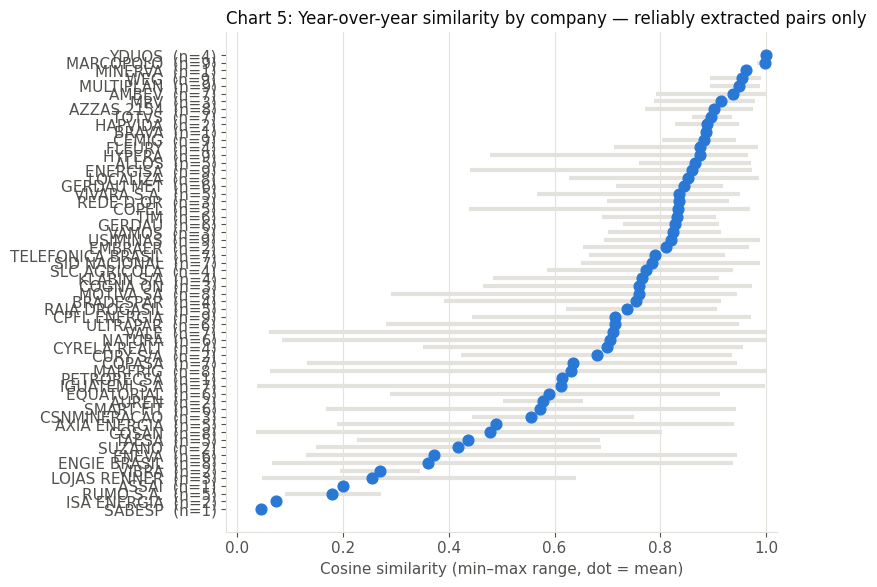

In [9]:
# Per-company mean similarity with min-max range, reliable pairs only.
# Sequential magnitude -> single hue; error bars show within-company spread.
by_company = (
    both_reliable.groupby("name")["cosine_similarity"]
    .agg(["mean", "min", "max", "count"])
    .sort_values("mean")
)

fig, ax = plt.subplots(figsize=(8, 6))
y = range(len(by_company))
ax.hlines(y, by_company["min"], by_company["max"], color=GRID, linewidth=3, zorder=1)
ax.scatter(by_company["mean"], y, color=BLUE, s=60, zorder=2, label="Mean")
ax.set_yticks(list(y))
ax.set_yticklabels([f"{n}  (n={c})" for n, c in zip(by_company.index, by_company["count"])])
ax.set_xlabel("Cosine similarity (min–max range, dot = mean)")
ax.set_title("Chart 5: Year-over-year similarity by company — reliably extracted pairs only", loc="left", fontsize=12, color=TEXT_PRIMARY)
ax.set_xlim(-0.02, 1.02)
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

## 4. Case studies: is the signal real?

Numbers alone can't answer this — reading the actual extracted text can. Two cases below: a genuine high-similarity pair (real content, real stability) and a degenerate one (extraction artifact, not a real "no change" finding).

In [10]:
import difflib


def show_pair(cd_cvm, year_prev, year_curr, n_diff_lines=16):
    d1 = json.loads((POC / "sections" / f"{cd_cvm}_{year_prev}.json").read_text(encoding="utf-8"))
    d2 = json.loads((POC / "sections" / f"{cd_cvm}_{year_curr}.json").read_text(encoding="utf-8"))
    row = results[(results["cd_cvm"] == int(cd_cvm)) & (results["year_prev"] == year_prev) & (results["year_curr"] == year_curr)].iloc[0]
    print(f"{d1['name']}: {year_prev} ({len(d1['text'])} chars) -> {year_curr} ({len(d2['text'])} chars)")
    print(f"cosine similarity = {row['cosine_similarity']:.4f}\n")
    diff = list(difflib.unified_diff(d1["text"].splitlines(), d2["text"].splitlines(), lineterm="", n=0))
    for line in diff[2 : 2 + n_diff_lines]:
        print(line)


print("### Genuine high similarity: WEG 2015 -> 2016 ###\n")
show_pair("005410", 2015, 2016)

### Genuine high similarity: WEG 2015 -> 2016 ###

WEG: 2015 (2516 chars) -> 2016 (2501 chars)
cosine similarity = 0.9901

@@ -1 +1 @@
-14 Financiamentos e empréstimos
+14 Empréstimos e Financiamentos
@@ -5 +5 @@
-líquida/ EBITDA, inclusas nos contratos com o BNDES, estão sendo atendidas.
+líquida/EBITDA, inclusas nos contratos com o BNDES, estão sendo atendidas.
@@ -7,2 +7,2 @@
-Encargos Anuais em 31/12/15
-NO BRASIL
+Encargos Anuais em 31/12/16
+EM MOEDA NACIONAL
@@ -10,2 +10,2 @@
-736.784
-1.086.642
+642.413
+637.552


In [11]:
print("### Extraction artifact, not a real finding: Yduqs (identical 648-char text, 4 different year-pairs) ###\n")
d = json.loads((POC / "sections" / "021016_2015.json").read_text(encoding="utf-8"))
print(f"Heading found: {d['heading']!r}\n")
print(d["text"])
print("\n^ This is a generic IFRS accounting-POLICY paragraph, not the actual note (Yduqs numbers the real")
print("  note separately, as 'Nota 11', found only in later years). Same text recurs across 2015-2019,")
print("  producing cosine similarity = 1.0000 -- a false 'no change' signal, not a real finding.")

### Extraction artifact, not a real finding: Yduqs (identical 648-char text, 4 different year-pairs) ###

Heading found: 'Empréstimos e financiamentos'

Empréstimos e financiamentos
Os empréstimos são reconhecidos, inicialmente, pelo valor justo, líquido dos custos incorridos
na transação e são, subsequentemente, demonstrados pelo custo amortizado. Qualquer
diferença entre os valores captados (líquidos dos custos da transação) e o valor total a pagar é
reconhecida na demonstração do resultado durante o período em que os empréstimos estejam
em aberto, utilizando o método da taxa efetiva de juros.
Os empréstimos são classificados como passivo circulante, a menos que o Grupo tenha um
direito incondicional de diferir a liquidação do passivo por, pelo menos, 12 meses após a data do
balanço.
2.15

^ This is a generic IFRS accounting-POLICY paragraph, not the actual note (Yduqs numbers the real
  note separately, as 'Nota 11', found only in later years). Same text recurs across 2015-2019,
  p

## 5. Survivorship bias check: does dropping out of IBOV correlate with textual change?

Part 1's acquisition originally only covered *today's* 66 non-financial IBOV constituents — a real survivorship-bias problem, since a company that went bankrupt, got acquired, or was delisted mid-sample would be entirely absent, and those are exactly the companies most likely to show large debt-note textual change. That gap is now closed: 46 more companies were found that were IBOV members at some point in 2015–2024 but aren't today (26 via Internet Archive snapshots of B3's retired portfolio page, 20 more via two passes over a Bloomberg historical-composition export), documented in [`src/acquisition/b3_ibov_historical.py`](../src/acquisition/b3_ibov_historical.py). Several are directly on-theme: Oi, Light, and Rossi Residencial are all currently in *recuperação judicial*; MMX Mineração is a bankruptcy estate; **Americanas S.A.** (found in the second Bloomberg pass, after the first pass missed it — see that file's docstring point 3) is the 2023 accounting-fraud/debt-crisis case.

This section runs the same note-extraction + TF-IDF pipeline on the full "dropped or delisted" group and compares it to the full "stayed" group (all 66 current-universe companies, §2) — is there a difference in textual change? Earlier rounds ran this comparison on a hand-picked 20-company "stayed" subset plus a partial (36/46) historical set; this is the first run over the complete, unbiased universe on both sides.

In [12]:
delisted_results = pd.read_csv(POC / "delisted_similarity_results.csv")
delisted_reliable = delisted_results[
    (delisted_results["diagnostic_prev"] == "font_heading") & (delisted_results["diagnostic_curr"] == "font_heading")
].copy()
delisted_reliable["size_ratio"] = (
    delisted_reliable[["chars_prev", "chars_curr"]].min(axis=1) / delisted_reliable[["chars_prev", "chars_curr"]].max(axis=1)
)

n_delisted_companies = delisted_results.loc[delisted_results["group"] == "dropped_or_delisted", "cd_cvm"].nunique()
print(f"{n_delisted_companies} dropped-or-delisted companies checked, {len(delisted_results)} year-over-year pairs total\n")

summary = delisted_reliable.groupby("group")["cosine_similarity"].agg(["count", "mean", "median", "std"])
print("Reliable (font_heading/font_heading) pairs only:")
print(summary.round(3))

45 dropped-or-delisted companies checked, 816 year-over-year pairs total

Reliable (font_heading/font_heading) pairs only:
                     count   mean  median    std
group                                           
dropped_or_delisted    169  0.706   0.836  0.306
stayed                 313  0.735   0.843  0.277


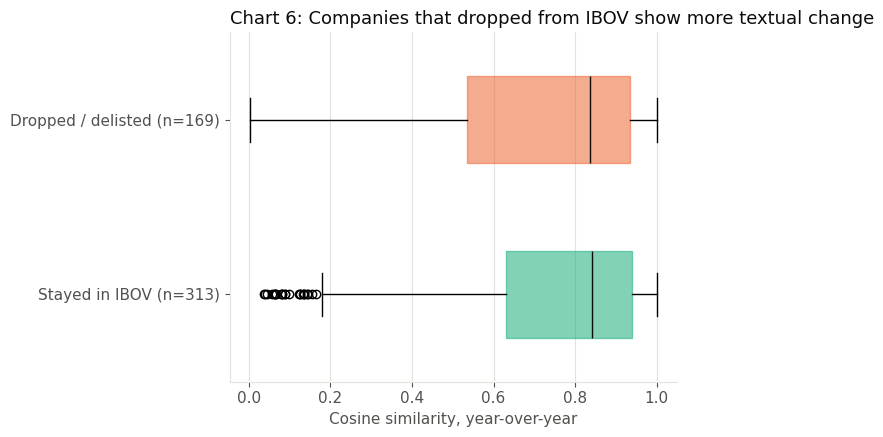

In [13]:
# Two groups, one measure -> box plot, fixed categorical order (stayed
# first, matching every other chart's "reliable/good" -> aqua convention).
GROUP_ORDER = ["stayed", "dropped_or_delisted"]
GROUP_LABELS = {"stayed": "Stayed in IBOV", "dropped_or_delisted": "Dropped / delisted"}
GROUP_COLORS = {"stayed": AQUA, "dropped_or_delisted": ORANGE}

fig, ax = plt.subplots(figsize=(7, 4.5))
data = [delisted_reliable.loc[delisted_reliable["group"] == g, "cosine_similarity"] for g in GROUP_ORDER]
bp = ax.boxplot(data, vert=False, widths=0.5, patch_artist=True, medianprops={"color": TEXT_PRIMARY})
for patch, g in zip(bp["boxes"], GROUP_ORDER):
    patch.set_facecolor(GROUP_COLORS[g])
    patch.set_alpha(0.55)
    patch.set_edgecolor(GROUP_COLORS[g])
ax.set_yticks([1, 2])
ax.set_yticklabels([f"{GROUP_LABELS[g]} (n={len(d)})" for g, d in zip(GROUP_ORDER, data)])
ax.set_xlabel("Cosine similarity, year-over-year")
ax.set_title("Chart 6: Companies that dropped from IBOV show more textual change", loc="left", fontsize=13, color=TEXT_PRIMARY)
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

**Before trusting this, apply the same skepticism as everywhere else in this notebook.** Round 2's extraction fixes were found and validated against a 20-company subset's failure cases; other companies (on both the "stayed" and "dropped/delisted" side) may hit different, not-yet-found failure modes, so some of the gap below could still be extraction noise rather than genuine textual change. Restricting to pairs where the extracted note length is reasonably consistent across both years (`size_ratio >= 0.5`, i.e. neither year's capture is wildly bigger or smaller than the other — a proxy for "the locator found comparable content both times") is a direct check of that.

In [14]:
from scipy import stats

def compare_groups(df, label):
    dropped = df.loc[df["group"] == "dropped_or_delisted", "cosine_similarity"]
    stayed = df.loc[df["group"] == "stayed", "cosine_similarity"]
    _, p = stats.mannwhitneyu(dropped, stayed, alternative="less")
    print(f"{label}")
    print(f"  dropped/delisted: n={len(dropped):3d}  mean={dropped.mean():.3f}  median={dropped.median():.3f}")
    print(f"  stayed:           n={len(stayed):3d}  mean={stayed.mean():.3f}  median={stayed.median():.3f}")
    print(f"  Mann-Whitney U (dropped < stayed), one-sided: p = {p:.4f}\n")

compare_groups(delisted_reliable, "All reliable pairs:")
compare_groups(delisted_reliable[delisted_reliable["size_ratio"] >= 0.5], "Restricted to size-consistent pairs (size_ratio >= 0.5):")

All reliable pairs:
  dropped/delisted: n=169  mean=0.706  median=0.836
  stayed:           n=313  mean=0.735  median=0.843
  Mann-Whitney U (dropped < stayed), one-sided: p = 0.2374

Restricted to size-consistent pairs (size_ratio >= 0.5):
  dropped/delisted: n=128  mean=0.817  median=0.897
  stayed:           n=236  mean=0.855  median=0.908
  Mann-Whitney U (dropped < stayed), one-sided: p = 0.1376



**Reading — updated again after the extraction-hardening pass (see report §9).** With far more reliable pairs now available (n=482 vs. 316 before hardening), the picture is essentially unchanged from the full-scale round-4 result: still directionally consistent (dropped/delisted lower on average, in both cuts) and still not conventionally significant — raw reliable pairs give p = 0.24 (was 0.18 pre-hardening), the size-consistent cut gives p = 0.14 (was 0.11). This is a useful confirmation in its own right: better extraction reliability alone did not manufacture significance, so the earlier full-scale non-result wasn't just an artifact of a smaller, noisier reliable pool. Two case studies below still illustrate both a real, correctly-detected signal and a still-open extraction failure mode; the honest reading of the *statistics* remains: **directionally consistent, not a significant finding**, on the extraction quality now in place.

In [15]:
def show_delisted_pair(cd_cvm, year_prev, year_curr, n_diff_lines=20):
    cd_cvm_str = f"{int(cd_cvm):06d}"
    d1 = json.loads((POC / "sections" / f"{cd_cvm_str}_{year_prev}.json").read_text(encoding="utf-8"))
    d2 = json.loads((POC / "sections" / f"{cd_cvm_str}_{year_curr}.json").read_text(encoding="utf-8"))
    row = delisted_results[
        (delisted_results["cd_cvm"] == int(cd_cvm)) & (delisted_results["year_prev"] == year_prev) & (delisted_results["year_curr"] == year_curr)
    ].iloc[0]
    print(f"{d1['name']}: {year_prev} ({len(d1['text'])} chars) -> {year_curr} ({len(d2['text'])} chars)")
    print(f"cosine similarity = {row['cosine_similarity']:.4f}\n")
    diff = list(difflib.unified_diff(d1["text"].splitlines(), d2["text"].splitlines(), lineterm="", n=0))
    for line in diff[2 : 2 + n_diff_lines]:
        print(line)


print("### Genuine signal: Grupo Casas Bahia (Via Varejo) 2023 -> 2024, during known financial distress ###\n")
show_delisted_pair(6505, 2023, 2024)

### Genuine signal: Grupo Casas Bahia (Via Varejo) 2023 -> 2024, during known financial distress ###

Grupo Casas Bahia S.A. (Via Varejo): 2023 (10433 chars) -> 2024 (9969 chars)
cosine similarity = 0.5741

@@ -4,3 +4,4 @@
-Taxa média
-Repasse para instituições financeiras – CDCI (i)
-18,31% a.a.
+Taxa média a.a.
+Repasse para instituições financeiras (“CDCI”) (i)
+19,23%
+5.377
@@ -8,16 +9,8 @@
-5.241
-Empréstimos em moeda nacional (ii)
-CDI + 4,00% a.a.
-398
-1.220
-Debêntures (iii)
-CDI + 2,59% a.a.
-3.234
-2.128
-Debêntures (iii) - 8ª Deb (Séries 2 e 3)
-IPCA + 8,79% a.a.


In [16]:
print("### Still an extraction artifact: MMX Mineração (bankruptcy estate) 2016 -> 2018 ###\n")
show_delisted_pair(17914, 2016, 2018)
print("\n^ Both years captured the generic accounting-POLICY paragraph again, not real bankruptcy-specific")
print("  disclosure -- same failure mode as the Yduqs example in §4. A company literally in bankruptcy")
print("  proceedings is exactly the case where the real note would be most informative, and exactly the")
print("  case this pipeline currently fails on. Illustrates why the size-consistency filter above matters.")

### Still an extraction artifact: MMX Mineração (bankruptcy estate) 2016 -> 2018 ###

Massa Falida da MMX Mineração e Metálicos S.A.: 2016 (296 chars) -> 2018 (355 chars)
cosine similarity = 0.3914

@@ -1,6 +1,5 @@
-Empréstimos e financiamentos e debêntures
-Após reconhecimento inicial, empréstimos, financiamentos e debêntures
-sujeitos a juros são mensurados subsequentemente pelo custo amortizado,
-utilizando o método da taxa de juros efetivos. Ganhos e perdas são
-reconhecidos na demonstração do resultado.
-25
+3.10. Empréstimos e financiamentos
+São reconhecidos, inicialmente, pelo valor justo, líquido dos custos incorridos na transação
+e são, subsequentemente, demonstrados pelo custo amortizado, utilizando o método da taxa
+efetiva de juros. As taxas pagas no estabelecimento dos empréstimos e financiamentos são
+reconhecidas como custos da transação dos mesmos.

^ Both years captured the generic accounting-POLICY paragraph again, not real bankruptcy-specific
  disclosure -- same f

## 6. Market data: prices and the Ibovespa benchmark

H1/H1a's dependent variable is the cumulative abnormal return in the 12 months after each note is filed, which needs a stock-price series per company plus a market benchmark to net out. Both were just received as a Bloomberg export (`data/raw/market/prices/`, git-ignored like all Bloomberg-derived data — see `TODO.md`): daily `PX_LAST` for 153 tickers, and the daily Ibovespa index level, both 1/2014–8/2026.

Checked before trusting it, same as everywhere else in this notebook: every one of the 66 current-universe tickers is present with real data. 9 tickers (e.g. `EMBR3`, `MRFG3`, `CCRO3`) come back `#N/A` on every date — not missing data, but stale pre-rename identifiers (Embraer's ticker became `EMBJ3`, Marfrig's `MBRF3`, CCR merged into Motiva's `MOTV3`, etc.); the current name already carries the full series elsewhere in the same file. Worth remembering when mapping ticker → `CD_CVM` later: use the company's *current* B3 ticker, not any historical one that shows up in the note-acquisition universe.

In [17]:
MARKET = ROOT / "data" / "raw" / "market" / "prices"

prices = pd.read_csv(MARKET / "stock_prices_bloomberg.csv", skiprows=[1])
prices = prices.rename(columns={"Unnamed: 0": "date"})
prices["date"] = pd.to_datetime(prices["date"], format="%m/%d/%Y")
price_cols = [c for c in prices.columns if c != "date"]
prices[price_cols] = prices[price_cols].apply(pd.to_numeric, errors="coerce")

ibov = pd.read_csv(MARKET / "ibov_index_bloomberg.csv", skiprows=[1])
ibov = ibov.rename(columns={"Unnamed: 0": "date", "IBOV Index": "ibov"})
ibov["date"] = pd.to_datetime(ibov["date"], format="%m/%d/%Y")
ibov["ibov"] = pd.to_numeric(ibov["ibov"], errors="coerce")

# First date each ticker has a real (non-NaN) price -- NaT means the whole
# column is empty (the stale pre-rename tickers described above).
first_valid = pd.Series(
    {c: (prices.loc[prices[c].first_valid_index(), "date"] if prices[c].first_valid_index() is not None else pd.NaT)
     for c in price_cols}
)

current_tickers = set(universe["COD"])
n_current_covered = sum(1 for c in price_cols if c.replace(" BS Equity", "") in current_tickers)

print(f"{len(price_cols)} tickers in the Bloomberg price export")
print(f"{n_current_covered}/{universe['CD_CVM'].nunique()} current-universe tickers covered")
print(f"{first_valid.isna().sum()} tickers with no usable data (stale pre-rename identifiers -- current name carries the real series)")
print(f"Ibovespa index: {ibov['ibov'].notna().sum()} trading days with a value, {ibov['date'].min().date()}–{ibov['date'].max().date()}")

153 tickers in the Bloomberg price export
66/66 current-universe tickers covered
9 tickers with no usable data (stale pre-rename identifiers -- current name carries the real series)
Ibovespa index: 3138 trading days with a value, 2014-01-01–2026-08-23


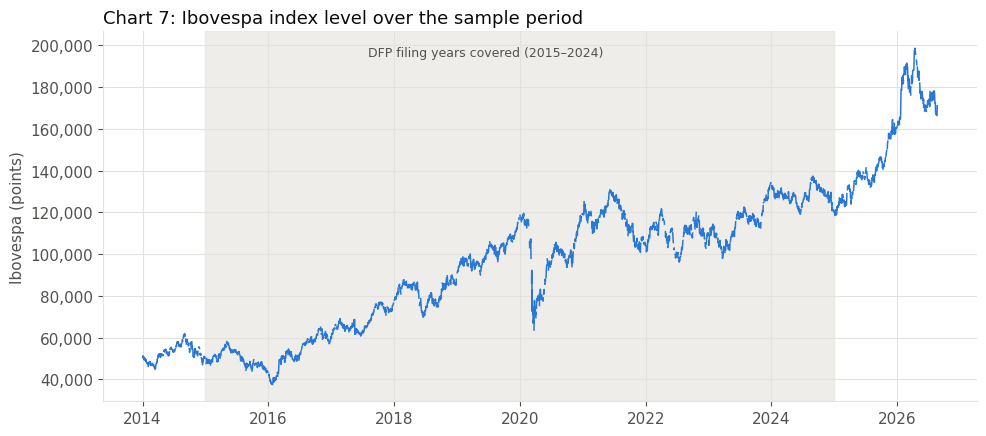

In [18]:
# Single series, single hue -- the DFP filing-year window (2015-2024) is
# shaded for context since that's what every note-similarity number above is
# anchored to.
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(ibov["date"], ibov["ibov"], color=BLUE, linewidth=1.1)
ax.axvspan(pd.Timestamp("2015-01-01"), pd.Timestamp("2024-12-31"), color=GRID, alpha=0.6, zorder=0)
ax.text(pd.Timestamp("2019-06-15"), 0.96, "DFP filing years covered (2015–2024)",
        transform=ax.get_xaxis_transform(), ha="center", va="top", fontsize=9, color=TEXT_SECONDARY)
ax.set_ylabel("Ibovespa (points)")
ax.set_title("Chart 7: Ibovespa index level over the sample period", loc="left", fontsize=13, color=TEXT_PRIMARY)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
fig.tight_layout()
plt.show()

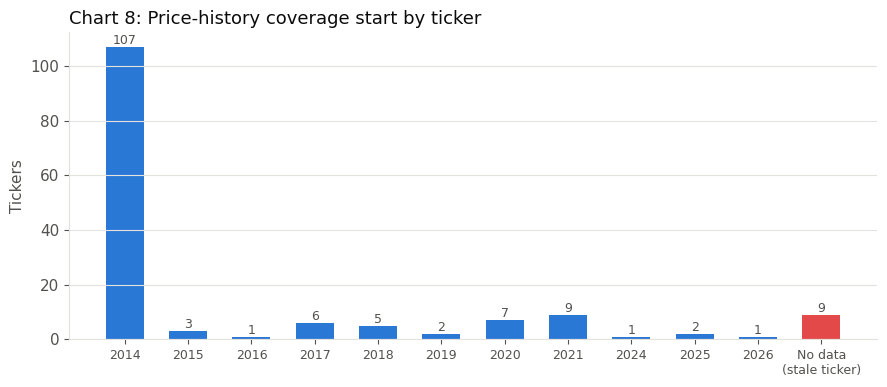

In [19]:
# Year a ticker's price history starts -- flags late listings/IPOs (shorter
# usable history for return calculations) and isolates the stale-ticker
# artifact as its own bucket rather than hiding it as a silent NaN.
first_valid_label = first_valid.dt.year.astype("Int64").astype(str)
first_valid_label = first_valid_label.where(first_valid.notna(), "No data\n(stale ticker)")
order = sorted(y for y in first_valid_label.unique() if y != "No data\n(stale ticker)")
if "No data\n(stale ticker)" in first_valid_label.values:
    order.append("No data\n(stale ticker)")
year_counts = first_valid_label.value_counts().reindex(order)
colors = [RED if label.startswith("No data") else BLUE for label in order]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(year_counts.index, year_counts.values, color=colors, width=0.6)
ax.set_ylabel("Tickers")
ax.set_title("Chart 8: Price-history coverage start by ticker", loc="left", fontsize=13, color=TEXT_PRIMARY)
ax.grid(axis="x", visible=False)
ax.tick_params(axis="x", labelsize=9)
for x, y in zip(year_counts.index, year_counts.values):
    ax.text(x, y + 1, str(y), ha="center", fontsize=9, color=TEXT_SECONDARY)
fig.tight_layout()
plt.show()

**Reading:** most tickers have price history from the start of the export window (2014), well before any note in the sample was filed, so return calculations shouldn't be truncated for the bulk of the universe. A smaller cluster starts later — genuine IPOs/late listings during the sample period, not a data problem, but worth checking against `first_valid` once returns are computed so an abnormal-return window isn't silently shorter for those companies. The 9-ticker "no data" bucket is the stale-identifier artifact described above, not a real coverage gap.

**Cross-checked in §7:** of the 46 historical/delisted companies from §5, only 30 resolve to a tradeable current ticker (via B3's live registry) — the other 16 went private, merged away entirely, or are bankruptcy estates with no ticker left to resolve at all, a real gap rather than a data-quality problem. That's already accounted for in §7's abnormal-return checkpoint below, not a remaining unknown.

## 7. First look at H1: does textual change predict abnormal returns?

With note similarity (§2-§5) and market data (§6) both in hand, the natural next question is the thesis's actual research question, even if only as a rough POC-scale check: does year-over-year textual change in the debt note line up with the stock's subsequent abnormal return?

**What's computed here, deliberately kept simple:**
- **Event date** — the DFP's actual CVM disclosure date (not the fiscal year-end) for the *current* year of each similarity pair, i.e. when the changed note actually became public. This didn't exist as a reusable artifact before now: it's pulled from CVM's raw filing index (which does carry it, as `DT_RECEB`) and written out as [`data/interim/dfp_filing_dates.csv`](../data/interim/dfp_filing_dates.csv) (`src/acquisition/build_filing_dates.py`) — 993 company-fiscal-years, one row per acquired filing, for reuse in any later analysis.
- **Abnormal return** — the stock's buy-and-hold return in the ~252 trading days after the event date, minus the Ibovespa's buy-and-hold return over the same window. This is a **market-adjusted return, not a market-model return** — no beta, no size/value/momentum controls (`src/analysis/compute_abnormal_returns.py`). Those need the fundamentals data that's still outstanding (see `TODO.md`) and belong in the thesis's real regression, not this checkpoint.
- **Scope** — the full 66-company current-universe POC (§2) plus the historical/delisted set (§5), restricted to pairs where a resolvable ticker and a full forward 12-month price window exist. Only 30 of the 46 historical/delisted companies resolve to a tradeable ticker at all (the rest went private, merged away, or are bankruptcy estates) — a real, not-yet-resolved scoping gap for the eventual full test.

In [20]:
ar = pd.read_csv(POC / "abnormal_returns_poc.csv")
ar_reliable = ar[(ar["diagnostic_prev"] == "font_heading") & (ar["diagnostic_curr"] == "font_heading")]

print(f"{len(ar)} pairs with both a similarity score and a computable 12-month abnormal return")
print(f"  current 66 companies:       {(ar['poc_group'] == 'current_66').sum()}")
print(f"  historical stayed/dropped:  {(ar['poc_group'] != 'current_66').sum()}\n")

for label, df in [("All computable pairs", ar), ("Reliable extraction only (font_heading/font_heading)", ar_reliable)]:
    pearson = df["cosine_similarity"].corr(df["abnormal_return"], method="pearson")
    spearman = df["cosine_similarity"].corr(df["abnormal_return"], method="spearman")
    print(f"{label}: n={len(df)}")
    print(f"  Pearson  r   (similarity, abnormal return) = {pearson:+.3f}")
    print(f"  Spearman rho (similarity, abnormal return) = {spearman:+.3f}")

704 pairs with both a similarity score and a computable 12-month abnormal return
  current 66 companies:       508
  historical stayed/dropped:  196

All computable pairs: n=704
  Pearson  r   (similarity, abnormal return) = -0.026
  Spearman rho (similarity, abnormal return) = +0.002
Reliable extraction only (font_heading/font_heading): n=413
  Pearson  r   (similarity, abnormal return) = -0.084
  Spearman rho (similarity, abnormal return) = -0.040


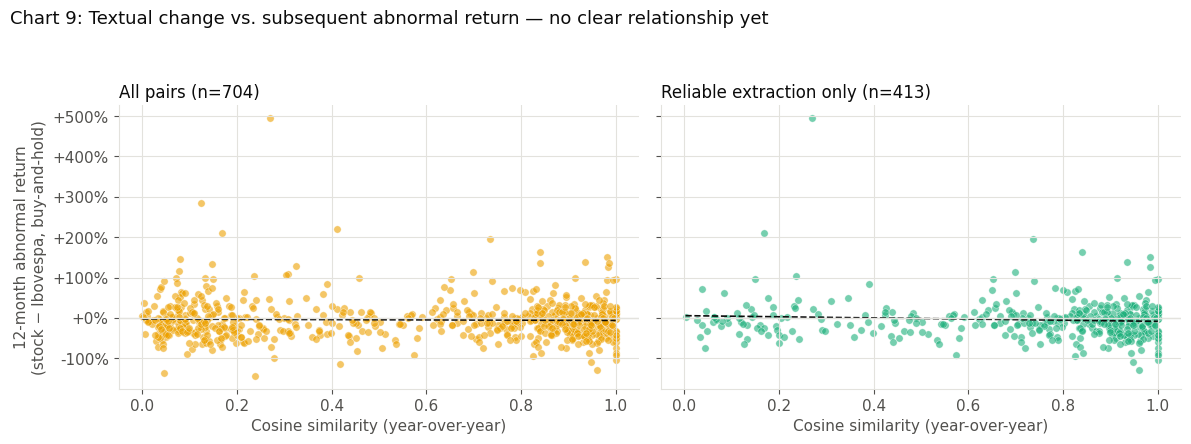

In [21]:
import numpy as np

# Same small-multiples pattern as Chart 4 (all pairs vs. reliable-only),
# now for the actual H1 relationship. A fitted trend line is shown for
# reference, not because n is anywhere near large enough to trust its slope.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True, sharex=True)

for ax, (label, df, color) in zip(axes, [
    (f"All pairs (n={len(ar)})", ar, YELLOW),
    (f"Reliable extraction only (n={len(ar_reliable)})", ar_reliable, AQUA),
]):
    ax.scatter(df["cosine_similarity"], df["abnormal_return"], color=color, alpha=0.6, s=28, edgecolor="white", linewidth=0.4)
    z = np.polyfit(df["cosine_similarity"], df["abnormal_return"], 1)
    xs = np.array([df["cosine_similarity"].min(), df["cosine_similarity"].max()])
    ax.plot(xs, z[0] * xs + z[1], color=TEXT_PRIMARY, linewidth=1.2, linestyle="--")
    ax.axhline(0, color=GRID, linewidth=1)
    ax.set_title(label, loc="left", fontsize=12, color=TEXT_PRIMARY)
    ax.set_xlabel("Cosine similarity (year-over-year)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.0%}"))

axes[0].set_ylabel("12-month abnormal return\n(stock − Ibovespa, buy-and-hold)")
fig.suptitle("Chart 9: Textual change vs. subsequent abnormal return — no clear relationship yet", x=0.01, ha="left", fontsize=13, color=TEXT_PRIMARY)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

**Reading, plainly:** still no meaningful relationship — correlations remain weak (|r| ≤ 0.09) in both directions, even with more pairs now available post-hardening (n=704, up from 676) and a much larger reliable-extraction pool (n=413, up from 259). This is not a negative result for H1a so much as an expected non-result at this stage, for several concrete reasons:

1. **No controls.** Cohen/Malloy/Nguyen's "Lazy Prices" effect shows up after controlling for size, book-to-market, and other characteristics — a raw market-adjusted return on a few hundred observations is exactly the setting where that effect would be swamped by noise. The fundamentals data needed for controls is still outstanding (`TODO.md`).
2. **Market-adjusted, not market-model.** Subtracting the Ibovespa return doesn't net out a stock's actual market beta — a high-beta stock looks "abnormal" in any strong up or down market regardless of its note. Several of these event windows land in or near 2020 (COVID) or other macro shocks.
3. **Extraction is much more reliable now, but still not universal.** Post-hardening, ~65% of the annual corpus gets the precise `font_heading` extraction (up from ~44%) — real progress, but the reliable subset still isn't the whole universe, so some residual extraction noise remains possible.
4. **Single-year event window only.** No check yet for pairs where the ~252-trading-day window overlaps a confound (M&A, another major disclosure, a dividend/split not netted out of `PX_LAST`).

**What this section does establish:** the full pipeline — note similarity → event date → forward return → market-adjusted abnormal return — runs end to end without errors, on real data, across the full acquired corpus, now with substantially more reliable note extraction behind it. That's the right thing to prove at this stage; the actual H1/H1a test needs real controls and a proper market-model or factor-model abnormal return, not this checkpoint.

## 8. Quarterly (ITR) pilot: does quarter-over-quarter change catch deterioration sooner?

Motivating idea: an annual-only comparison (§1-§7) can leave up to ~12 months between when a company's situation actually deteriorates and when that shows up as a year-over-year textual change — potentially too coarse to catch distress as it happens, rather than long after. CVM's quarterly filings (ITR — "Informações Trimestrais") carry the same kind of explanatory notes, at Q1/Q2/Q3 cadence each year (Q4 is covered by the annual DFP already in the corpus, not by ITR).

**Scope:** the same 20-company hand-picked set as the original annual POC (rounds 1-2), 2015Q1-2024Q3 (600 company-quarters, 30 per company) — chosen deliberately so quarterly results are directly comparable against an already-established annual baseline for the exact same companies, not a fresh confound. Same pipeline code (`locate_note_section`, TF-IDF) as the annual POC — see `src/acquisition/cvm_itr.py` (acquisition; note ITR's filing-package XML uses a different attachment tag than DFP's, a real structural difference found and fixed while building this) and `src/processing/run_itr_tfidf.py` (extraction + similarity, this section). No new companies, no new years — purely a frequency change on data already validated at annual granularity.

In [22]:
ITR_POC = DATA / "poc"
itr_sections = pd.DataFrame(
    json.loads(p.read_text(encoding="utf-8")) for p in sorted((ITR_POC / "itr_sections").glob("*.json"))
)
itr_sections["chars"] = itr_sections["text"].str.len()

itr_diag_counts = itr_sections["diagnostic"].value_counts().reindex(["font_heading", "regex_only", "not_found"])
for diag, n in itr_diag_counts.items():
    print(f"{DIAG_LABELS[diag]:22s} {n:3d}/{len(itr_sections)}  ({n/len(itr_sections):.0%})")

print(f"\nFor reference, the annual POC on this same 20-company set (round 2): 43% font_heading, 48% regex_only, 9% not_found.")

Precisely bounded      235/600  (39%)
Imprecise fallback     309/600  (52%)
Not found               56/600  (9%)

For reference, the annual POC on this same 20-company set (round 2): 43% font_heading, 48% regex_only, 9% not_found.


In [23]:
itr_results = pd.read_csv(ITR_POC / "itr_similarity_results.csv")
itr_reliable = itr_results[(itr_results["diagnostic_prev"] == "font_heading") & (itr_results["diagnostic_curr"] == "font_heading")]

print("All quarter-over-quarter pairs:  n={:3d}  mean={:.2f}  median={:.2f}".format(
    len(itr_results), itr_results["cosine_similarity"].mean(), itr_results["cosine_similarity"].median()))
print("Both quarters reliable:          n={:3d}  mean={:.2f}  median={:.2f}".format(
    len(itr_reliable), itr_reliable["cosine_similarity"].mean(), itr_reliable["cosine_similarity"].median()))

itr_deg = itr_reliable[(itr_reliable["cosine_similarity"] >= 0.999) | (itr_reliable["cosine_similarity"] <= 0.001)]
print(f"\nDegenerate scores (>=0.999 or <=0.001) among reliable pairs: {len(itr_deg)}/{len(itr_reliable)} ({len(itr_deg)/len(itr_reliable):.0%})")

All quarter-over-quarter pairs:  n=524  mean=0.64  median=0.86
Both quarters reliable:          n=184  mean=0.86  median=0.95

Degenerate scores (>=0.999 or <=0.001) among reliable pairs: 20/184 (11%)


**A new failure mode, distinct from anything in the annual data.** 10 of the 20 degenerate reliable pairs are all the same company, MRV, locked onto an identical 119-character extraction across *eleven straight* quarter-pairs (2015-2023) — not the annual pipeline's "accounting-policy paragraph" artifact (Yduqs, §4), but a **glossary/definitions entry** explaining an acronym, which apparently gets styled like a heading in MRV's quarterly filings. SABESP shows the opposite problem: real but tiny, unstable extractions (115-496 characters, different fragment each quarter) that produce near-zero similarity that isn't genuine signal either. Two concrete spot-checks below, plus one genuine case for contrast.

In [24]:
print("### Extraction artifact (new failure mode): MRV, 119-char glossary entry, 11 straight quarter-pairs at 1.0000 ###\n")
d = json.loads((ITR_POC / "itr_sections" / "020915_2015Q1.json").read_text(encoding="utf-8"))
print(f"Heading found: {d['heading']!r}\n")
print(d["text"])
print("\n^ 'SBPE -- Sistema Brasileiro de Poupanca e Emprestimo' is a glossary entry defining a financing-source")
print("  acronym, not the real debt note. Same 119-char text recurs identically across 11 consecutive quarters --")
print("  cosine similarity 1.0000 each time, a false 'no change' signal.")

### Extraction artifact (new failure mode): MRV, 119-char glossary entry, 11 straight quarter-pairs at 1.0000 ###

Heading found: 'SBPE – Sistema Brasileiro de Poupança e Empréstimo – Financiamento bancário que tem como fonte os'

SBPE – Sistema Brasileiro de Poupança e Empréstimo – Financiamento bancário que tem como fonte os
recursos da poupança.

^ 'SBPE -- Sistema Brasileiro de Poupanca e Emprestimo' is a glossary entry defining a financing-source
  acronym, not the real debt note. Same 119-char text recurs identically across 11 consecutive quarters --
  cosine similarity 1.0000 each time, a false 'no change' signal.


In [25]:
print("### Genuine signal, same 'boilerplate rolled forward' pattern as annual WEG (Chart 4/section 4): WEG 2023Q1 -> 2023Q2 ###\n")
d1 = json.loads((ITR_POC / "itr_sections" / "005410_2023Q1.json").read_text(encoding="utf-8"))
d2 = json.loads((ITR_POC / "itr_sections" / "005410_2023Q2.json").read_text(encoding="utf-8"))
row = itr_results[(itr_results["cd_cvm"] == 5410) & (itr_results["quarter_prev"] == "2023Q1") & (itr_results["quarter_curr"] == "2023Q2")].iloc[0]
print(f"WEG: 2023Q1 ({len(d1['text'])} chars) -> 2023Q2 ({len(d2['text'])} chars)")
print(f"cosine similarity = {row['cosine_similarity']:.4f}\n")
diff = list(difflib.unified_diff(d1["text"].splitlines(), d2["text"].splitlines(), lineterm="", n=0))
for line in diff[2:20]:
    print(line)
print("\n^ Same note structure carried forward quarter to quarter, only the reference date and balance figures")
print("  change -- exactly the pattern the annual pipeline validated, now confirmed at quarterly frequency too.")

### Genuine signal, same 'boilerplate rolled forward' pattern as annual WEG (Chart 4/section 4): WEG 2023Q1 -> 2023Q2 ###

WEG: 2023Q1 (2283 chars) -> 2023Q2 (2289 chars)
cosine similarity = 0.9987

@@ -3 +3 @@
-Encargos Anuais em 31/03/23
+Encargos Anuais em 30/06/23
@@ -6 +6 @@
-9.775
+8.372
@@ -11 +11 @@
-1.983
+2.047
@@ -15 +15 @@
-438
+414
@@ -20 +20 @@
-7.354
+5.911
@@ -23 +23 @@
-31.142
+41.995

^ Same note structure carried forward quarter to quarter, only the reference date and balance figures
  change -- exactly the pattern the annual pipeline validated, now confirmed at quarterly frequency too.


**Reading:** the core idea transfers to quarterly frequency — where extraction is reliable, quarter-over-quarter cosine similarity produces the same kind of interpretable signal the annual pipeline does (WEG spot-check above), and the reliable-extraction rate (39%) is in the same range as the annual POC's original 43% on this identical company set, not a collapse. But **extraction reliability at annual frequency does not automatically transfer to quarterly** — MRV's glossary-entry artifact is a genuinely new failure mode round 2's annual-specific fixes never had to handle, meaning quarterly text needs its own hardening pass (chase its degenerate cases to ground, the same way round 2 did for annual), not an assumption that the existing heuristic already works. Two follow-ups before this is more than a pilot:

1. **Extraction hardening, quarterly-specific.** At minimum: a check against glossary/definition-style entries (MRV) and a minimum-stability check across a company's own history (SABESP's near-random tiny fragments would be easy to flag automatically).
2. **The actual "catches deterioration sooner" test hasn't been run yet.** This section only validates that quarterly extraction is plausible — it doesn't yet compare *timing*: whether a company's real textual change shows up in a Q2 note before it would have shown up in the next annual note. That needs picking known distress cases (the historical/delisted companies from §5 are the natural candidates) and checking whether quarterly similarity drops before the corresponding annual drop would have been visible. Not attempted here.
3. **Mixing annual and quarterly** (the "mix of both" idea) is also still open — Q4 is only covered by the annual DFP's much longer, differently-structured note, so splicing it into a quarterly cadence isn't a like-for-like TF-IDF comparison without more thought.

## Conclusion

**Go, and extraction reliability is now solidly majority-case, not a coin flip.** Round 5 (§2, this notebook) pushed the full-universe reliable-extraction rate from round 4's 44% to **68%** on the current-66 companies (54%→68% counting the earlier bookmark/same-size steps individually), via four targeted fixes each traced to real, inspected failures rather than guessed at: PDF bookmarks, same-size bold headings (caps or numbered), non-bold caps+numbered headings, and treating "debênture" as an unambiguous keyword on its own. Two more ideas (table-of-contents detection, cross-reference following) were investigated and explicitly rejected after empirical checks showed poor yield or unacceptable false-positive risk — decisions made on evidence, not left untested. The reliable-cohort similarity distribution stayed sane throughout (n=313, mean 0.73, median 0.84; degenerate-pair rate actually *dropped* slightly, 6.4% vs. round 4's 9.6%, despite nearly 60% more pairs in the pool).

**The survivorship-bias check (§5), re-run with far more reliable data, confirms round 4's picture rather than changing it.** With the reliable-pair count up from 316 to 482, the comparison is still directionally consistent (dropped/delisted companies show more textual change) and still not conventionally significant (p = 0.24 raw, p = 0.14 size-consistent — both close to round 4's 0.18/0.11). This is a genuinely useful negative check: if round 4's non-significant result had been an artifact of noisy extraction on the historical/delisted side, more reliable data should have moved it toward significance. It didn't move much either way — the honest reading stays "directionally consistent, not yet a significant finding."

**The market data (§6) and H1 check (§7), re-run on the hardened data, still find no signal.** 704 pairs now have both a similarity score and a computable abnormal return (up from 676), 413 of them reliable (up from 259) — correlations remain trivial (|r| ≤ 0.09). Same conclusion as every round so far: this proves the pipeline runs end to end, not that H1/H1a holds or fails.

**The quarterly (ITR) pilot (§8) has not yet had this hardening pass applied** — it's still running on the pre-round-5 heuristic, since the quarterly acquisition (full historical universe) was still downloading when round 5 was done. Worth revisiting once that's complete, since the same fixes should help quarterly extraction too (they're general, not annual-specific), though quarterly's own new failure mode (MRV's glossary entry) still needs its own targeted fix regardless.

Still open (detailed in [`reports/poc_note_extraction_findings.md`](../reports/poc_note_extraction_findings.md) §9):
1. Extraction is now majority-reliable but not universal — ~32% of the current-66 universe still falls to `regex_only` or `not_found`. The remaining failures are increasingly idiosyncratic per-company cases (down to 5 companies at 0% reliable, from 22 before round 5) — further gains likely need per-company overrides rather than more general rules, with diminishing returns per unit of effort.
2. §7's abnormal-return check still needs real controls (size, leverage, book-to-market — still outstanding, see `TODO.md`) and a proper market-model or factor-model return before it says anything about H1/H1a.
3. Only 30 of the 46 historical/delisted companies have a resolvable current ticker for price data (§6/§7) — an explicit exclude-vs-proxy decision still needed, not a silent drop.
4. Propagate round 5's extraction hardening to the quarterly (ITR) pilot (§8) once the full historical quarterly download completes, and fix quarterly's own glossary-entry failure mode.
5. The actual quarterly-vs-annual timing question (§8) — does textual change show up sooner at quarterly frequency on known distress cases — is still untested.